# Setup

## Imports

In [1]:
import pandas as pd
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from src.preprocessing import (
    filter_low_magnitude_genes,
    filter_high_apoptosis_cells,
    normalize_by_library_size,
    log_transform,
    normalize_data_with_pearson,
    genes,
    filter_doublets
)
from src.visualization import (
    plot_gene_magnitude_distribution,
    plot_normalization_comparison,
    plot_log_transform_comparison,
    plot_pearson_diagnostic,
    plot_metric_distribution,
    calculate_gene_fraction
)
from src.utils import extract_gene_subset

## Data Loading

In [4]:
from src.data_loading import load_csv_data

DATA_PATH = '../data/GSE45719/raw/mouse.embryo.GS45719.expression_matrix.csv.gz'
raw_data = load_csv_data(DATA_PATH)
raw_data = raw_data.T

raw_data.shape

(268, 22431)

# Gene Filtering

In [5]:
clean_data = filter_low_magnitude_genes(raw_data)

clean_data.head()

  • Dropped 2552 low-magnitude genes


,Hvcn1,Gbp7,Arrdc1,Ercc5,Mrpl15,Dclk1,Tssc4,Gm101,Pum2,Erv3,...,Gm13288,0610043K17Rik,1700125G02Rik,4930465A12Rik,1700003M07Rik,Slc30a2,4930515B02Rik,1810035I16Rik,Sox5,Alg11
GSM1112490,2,0,2246,1,2259,0,476,0,5144,0,...,0,0,0,0,0,0,0,0,0,9
GSM1112491,147,0,746,1,1614,0,708,0,3096,0,...,0,0,0,0,0,0,0,0,0,128
GSM1112492,0,0,1410,0,3969,0,517,0,4654,0,...,0,0,0,0,0,0,0,1,0,15
GSM1112493,103,0,727,0,3657,0,0,0,3337,0,...,0,0,0,0,0,0,0,0,0,94
GSM1112494,0,0,1682,132,5493,0,263,0,5213,0,...,0,0,0,0,0,17,0,7,0,69


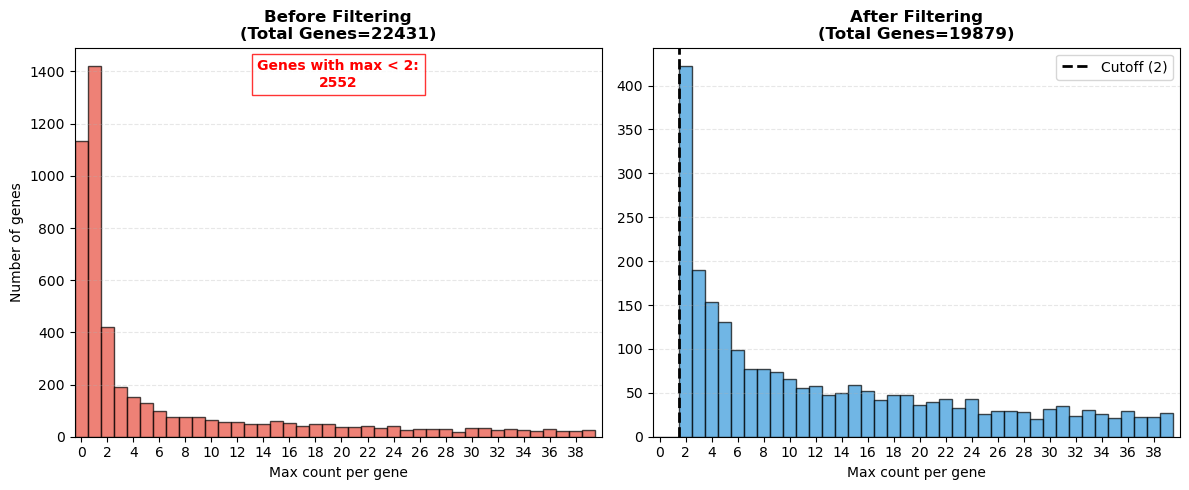

In [6]:
plot_gene_magnitude_distribution(raw_data, clean_data, x_limit=40)

# Quality Control (Cell Filtering)

## Mitochondrial

In [7]:
# Check if any starts with "MT-" (Human)
print("'MT-' genes:", clean_data.columns.str.startswith('MT-').sum())

'MT-' genes: 0


## Apoptosis

In [8]:
apoptosis_data = extract_gene_subset(clean_data, genes.HUMAN_APOPTOSIS_GENES, "Apoptosis")

Apoptosis: Matched 1 of 161 reference genes.


## rRNA

In [10]:
rrna_data = extract_gene_subset(clean_data, genes.HUMAN_RRNA_GENES, "rRNA")

rRNA: Matched 0 of 552 reference genes.


## Doublets

In [11]:
no_doublets_data = filter_doublets(clean_data)

  • Dropped 16 doublets


# Normalization

## logCPM

### Normalize by library size

In [12]:
normalized_data = normalize_by_library_size(no_doublets_data)

normalized_data.shape

  • Normalizing library size (rescale=1e+06)


(252, 19879)

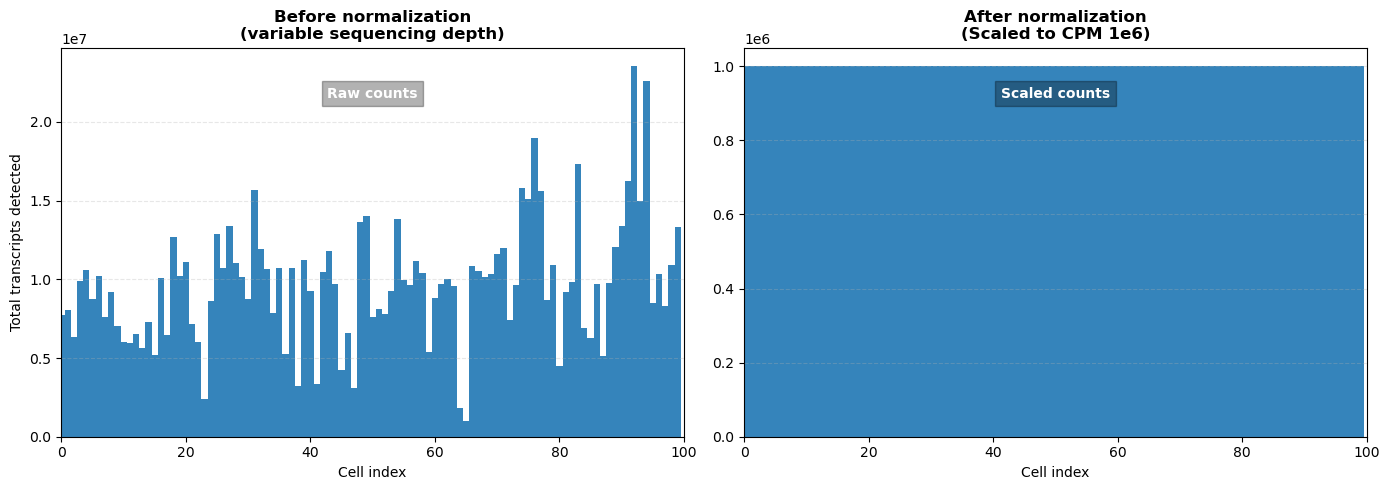

In [13]:
plot_normalization_comparison(no_doublets_data, normalized_data)

### Log Transform

In [14]:
logged_data = log_transform(normalized_data)

logged_data.shape

  • Applying log transform (log1+x)


(252, 19879)

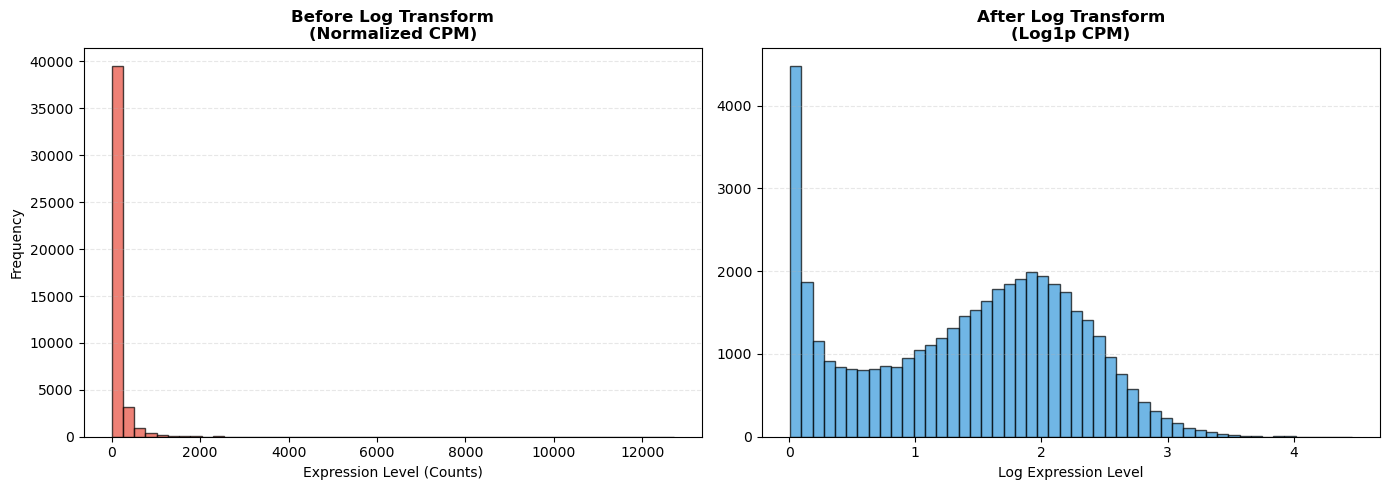

In [15]:
plot_log_transform_comparison(normalized_data, logged_data)

## Pearson residuals

In [16]:
pearsons_data = normalize_data_with_pearson(no_doublets_data)

pearsons_data.shape

  • Computing residuals for 252 cells
  • Selecting top 3000 variable genes


(252, 3000)

In [17]:
pearsons_data.head()

,Arrdc1,Tssc4,Mapk9,AW549877,Stac2,Dlc1,2700078E11Rik,Coro7,Mios,Pus10,...,Git1,Atg9a,AI413582,Nlrp14,H2-K1,Atp8b1,Atp6v0a1,Bcat2,Arntl,Alg11
GSM1112491,3.955822,15.874508,-8.718891,-7.922639,15.874508,4.610720,15.874508,-7.616416,12.108228,3.568476,...,6.224176,8.061919,-6.741423,-8.871133,0.591760,-8.542717,-8.206625,-9.394960,-8.898829,-3.124422
GSM1112492,13.354451,15.874508,-7.809229,-8.068070,-2.196579,-7.966767,-5.452421,-7.774655,-8.807002,-8.650790,...,-8.616940,8.599218,2.869147,-9.718509,-8.783350,5.599767,-0.407842,15.874508,-8.967678,-7.793344
GSM1112493,5.657291,-7.190308,-5.580772,-5.989208,-2.553504,-7.626774,-3.416992,-7.365386,2.344733,-8.314858,...,-2.970761,9.213301,7.303225,-8.035039,-8.474659,-8.214070,15.874508,-8.339535,-8.722991,-3.758686
GSM1112494,13.942027,4.943354,-9.070174,-8.281104,13.041962,-7.993328,1.490593,-8.008525,8.136378,-8.839317,...,10.484502,7.922247,3.434854,-9.748192,-7.124185,-8.818055,-6.548958,-8.750283,-9.117268,-6.331078
GSM1112495,-9.390997,-8.007983,-9.060087,-8.410160,15.874508,-7.820569,15.184724,-7.369342,-9.082259,-7.850621,...,15.874508,15.144124,-7.889492,-7.292340,-0.463287,-8.914663,15.874508,-9.424244,-9.192754,15.874508
